In [369]:
import numpy as np

import pandas as pd
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf

In [370]:
df = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-11/segmentation_data.csv")

In [371]:
df.shape

(15000, 20)

In [372]:
df.dtypes[:]

Age                        int64
Gender                       str
Education Level              str
Marital Status               str
Income                   float64
Credit Score             float64
Loan Amount              float64
Loan Purpose                 str
Employment Status            str
Years at Current Job       int64
Payment History              str
Debt-to-Income Ratio     float64
Assets Value             float64
Number of Dependents     float64
City                         str
State                        str
Country                      str
Previous Defaults        float64
Marital Status Change      int64
Risk Rating                  str
dtype: object

# <b>`Preprocessing`

In [373]:
df.isnull().sum()[:]

Age                         0
Gender                      0
Education Level             0
Marital Status              0
Income                   2250
Credit Score             2250
Loan Amount              2250
Loan Purpose                0
Employment Status           0
Years at Current Job        0
Payment History             0
Debt-to-Income Ratio        0
Assets Value             2250
Number of Dependents     2250
City                        0
State                       0
Country                     0
Previous Defaults        2250
Marital Status Change       0
Risk Rating                 0
dtype: int64

In [374]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['Age', 'Income', 'Credit Score', 'Loan Amount', 'Years at Current Job',
       'Debt-to-Income Ratio', 'Assets Value', 'Number of Dependents',
       'Previous Defaults', 'Marital Status Change'],
      dtype='str')

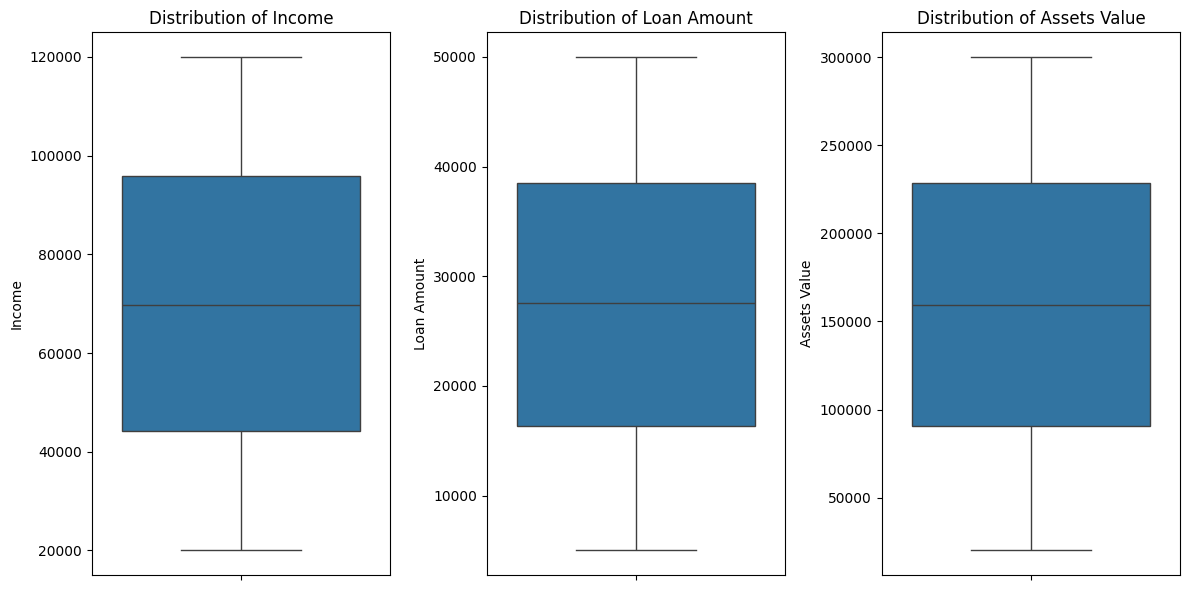

In [375]:
# Income Loan Amount Assets Value                
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['Income'])
plt.title('Distribution of Income')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['Loan Amount'])
plt.title('Distribution of Loan Amount')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['Assets Value'])
plt.title('Distribution of Assets Value')

plt.tight_layout()
plt.show()

In [376]:
col = ['Income', 'Loan Amount', 'Assets Value']
for c in col:
    skew = round(df[c].skew(), 4)
    print(f"Skewness of {c}: {skew}")

Skewness of Income: 0.0104
Skewness of Loan Amount: -0.0014
Skewness of Assets Value: 0.0016


In [377]:
df['Loan Purpose'].value_counts()   

Loan Purpose
Personal    3771
Home        3766
Business    3738
Auto        3725
Name: count, dtype: int64

In [378]:
df_copy = df[~ (df['Income'].isna()) ].copy()

In [379]:
df_copy.isna().sum()

Age                         0
Gender                      0
Education Level             0
Marital Status              0
Income                      0
Credit Score             1916
Loan Amount              1913
Loan Purpose                0
Employment Status           0
Years at Current Job        0
Payment History             0
Debt-to-Income Ratio        0
Assets Value             1921
Number of Dependents     1907
City                        0
State                       0
Country                     0
Previous Defaults        1935
Marital Status Change       0
Risk Rating                 0
dtype: int64

In [380]:
df_copy = df_copy[~df_copy['Credit Score'].isna()]

In [381]:
df_copy = df_copy[~df_copy['Previous Defaults'].isna()]

In [382]:
df_copy.fillna(0.0, inplace=True)

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688.0,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0.0,Port Elizabeth,AS,Cyprus,2.0,2,Low
2,21,Non-binary,Master's,Single,55687.0,600.0,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3.0,South Scott,OK,Luxembourg,3.0,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622.0,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3.0,Robinhaven,PR,Uganda,4.0,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766.0,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,0.0,New Heather,IL,Namibia,3.0,1,Low
6,31,Non-binary,Master's,Widowed,45280.0,672.0,6553.0,Personal,Self-employed,1,Good,0.378890,0.0,0.0,West Lindaview,MD,Bouvet Island (Bouvetoya),0.0,1,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,40,Male,High School,Married,43655.0,614.0,34565.0,Home,Unemployed,11,Poor,0.399901,32179.0,4.0,Curtismouth,IA,Uzbekistan,1.0,1,Low
14995,23,Non-binary,Bachelor's,Widowed,48088.0,609.0,26187.0,Home,Self-employed,2,Fair,0.317633,0.0,4.0,Susanstad,TN,Djibouti,2.0,0,Low
14996,56,Male,PhD,Single,107193.0,700.0,35111.0,Auto,Self-employed,10,Fair,0.155126,79102.0,0.0,Port Heather,WA,Congo,0.0,0,Medium
14997,29,Non-binary,PhD,Married,46250.0,642.0,44369.0,Home,Unemployed,19,Excellent,0.593999,196930.0,4.0,South Morganchester,LA,Palau,2.0,1,High


In [383]:
df_copy.isna().sum()

Age                      0
Gender                   0
Education Level          0
Marital Status           0
Income                   0
Credit Score             0
Loan Amount              0
Loan Purpose             0
Employment Status        0
Years at Current Job     0
Payment History          0
Debt-to-Income Ratio     0
Assets Value             0
Number of Dependents     0
City                     0
State                    0
Country                  0
Previous Defaults        0
Marital Status Change    0
Risk Rating              0
dtype: int64

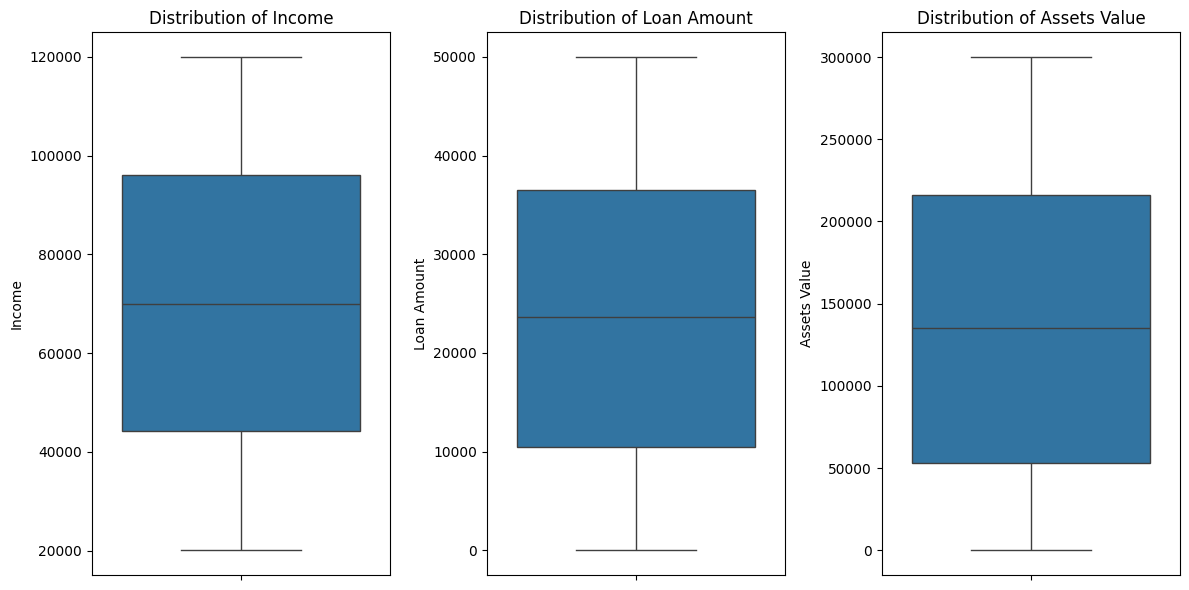

In [384]:
# Income Loan Amount Assets Value                
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_copy['Income'])
plt.title('Distribution of Income')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_copy['Loan Amount'])
plt.title('Distribution of Loan Amount')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_copy['Assets Value'])
plt.title('Distribution of Assets Value')

plt.tight_layout()
plt.show()

In [385]:
df_copy.select_dtypes(include=['float64']).columns.tolist()

['Income',
 'Credit Score',
 'Loan Amount',
 'Debt-to-Income Ratio',
 'Assets Value',
 'Number of Dependents',
 'Previous Defaults']

In [386]:
df_copy['Number of Dependents'] = df_copy['Number of Dependents'].astype('int64', errors='ignore')
df_copy['Previous Defaults'] = df_copy['Previous Defaults'].astype('int64', errors='ignore')
df_copy['Credit Score'] = df_copy['Credit Score'].astype('int64', errors='ignore')

In [387]:
df_copy.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799.0,688,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0,Port Elizabeth,AS,Cyprus,2,2,Low
2,21,Non-binary,Master's,Single,55687.0,600,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3,South Scott,OK,Luxembourg,3,2,Medium
3,59,Male,Bachelor's,Single,26508.0,622,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3,Robinhaven,PR,Uganda,4,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427.0,766,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,0,New Heather,IL,Namibia,3,1,Low
6,31,Non-binary,Master's,Widowed,45280.0,672,6553.0,Personal,Self-employed,1,Good,0.378890,0.0,0,West Lindaview,MD,Bouvet Island (Bouvetoya),0,1,Low


<b> Making a different datset for Model Training

In [388]:
df_model = df_copy.copy()

In [389]:
cols = ['Income', 'Credit Score',
        'Loan Amount', 'Assets Value',
        'Number of Dependents', 'Previous Defaults']

for col in cols:
    df_model[col] = df_model[col].astype('int64', errors='ignore')

df_model['Debt-to-Income Ratio'] = df_model['Debt-to-Income Ratio'].round(2)

In [390]:
df_model.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating
0,49,Male,PhD,Divorced,72799,688,45713,Business,Unemployed,19,Poor,0.15,120228,0,Port Elizabeth,AS,Cyprus,2,2,Low
2,21,Non-binary,Master's,Single,55687,600,36623,Home,Employed,8,Fair,0.36,180700,3,South Scott,OK,Luxembourg,3,2,Medium
3,59,Male,Bachelor's,Single,26508,622,26541,Personal,Unemployed,2,Excellent,0.45,157319,3,Robinhaven,PR,Uganda,4,2,Medium
4,25,Non-binary,Bachelor's,Widowed,49427,766,36528,Personal,Unemployed,10,Fair,0.14,287140,0,New Heather,IL,Namibia,3,1,Low
6,31,Non-binary,Master's,Widowed,45280,672,6553,Personal,Self-employed,1,Good,0.38,0,0,West Lindaview,MD,Bouvet Island (Bouvetoya),0,1,Low


# <b>`Exploratory Data Analysis`

In [391]:
def RFS1(x):
    r = 1 if (x['Credit Score'] >= 699 and 
              x['Previous Defaults'] < 2 and 
              x['Risk Rating'] == 'Low') else 0

    f = 1 if (x['Income'] > 69933 and 
              x['Assets Value'] > 159742 and 
              x['Loan Amount'] < 27450 and 
              x['Debt-to-Income Ratio'] <= 0.35) else 0

    s = 1 if (x['Years at Current Job'] >= 9 and 
              x['Payment History'] in {'Excellent', 'Good'}) else 0

    return dict_rfm[str(r) + str(f) + str(s)]

dict_rfm = {
    '111': 'High Net-Worth Prime',      # Top-tier clients with strong financial position, stability, and low risk
    '011': 'Premium Watchlist',         # Wealthy, stable but flagged for recent credit/risk events
    '101': 'Volatile Affluent',         # Wealthy, creditworthy but recent instability in income or status
    '001': 'Asset-Heavy Prospect',      # Significant assets, but lacking stability and reliable financial behavior
    '110': 'Growth Stable',             # Reliable/stable client showing potential for strong asset accumulation
    '100': 'Emerging Profile',          # Newly engaged client, recent credit/event, financial potential uncertain
    '010': 'Consistent Moderate',       # Stable but lacking strong financial standing or asset base, some reliability
    '000': 'Low Engagement'             # No strong financial, stability, or credit characteristics; low contributor
}

In [392]:
df_analysis = df_copy.copy()
df_analysis['Label'] = df_analysis.apply(RFS1, axis=1)
df_analysis.head()

,Age,Gender,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,City,State,Country,Previous Defaults,Marital Status Change,Risk Rating,Label
0,49,Male,PhD,Divorced,72799.0,688,45713.0,Business,Unemployed,19,Poor,0.154313,120228.0,0,Port Elizabeth,AS,Cyprus,2,2,Low,Low Engagement
2,21,Non-binary,Master's,Single,55687.0,600,36623.0,Home,Employed,8,Fair,0.362398,180700.0,3,South Scott,OK,Luxembourg,3,2,Medium,Low Engagement
3,59,Male,Bachelor's,Single,26508.0,622,26541.0,Personal,Unemployed,2,Excellent,0.454964,157319.0,3,Robinhaven,PR,Uganda,4,2,Medium,Low Engagement
4,25,Non-binary,Bachelor's,Widowed,49427.0,766,36528.0,Personal,Unemployed,10,Fair,0.143242,287140.0,0,New Heather,IL,Namibia,3,1,Low,Low Engagement
6,31,Non-binary,Master's,Widowed,45280.0,672,6553.0,Personal,Self-employed,1,Good,0.378890,0.0,0,West Lindaview,MD,Bouvet Island (Bouvetoya),0,1,Low,Low Engagement


## `Plots`

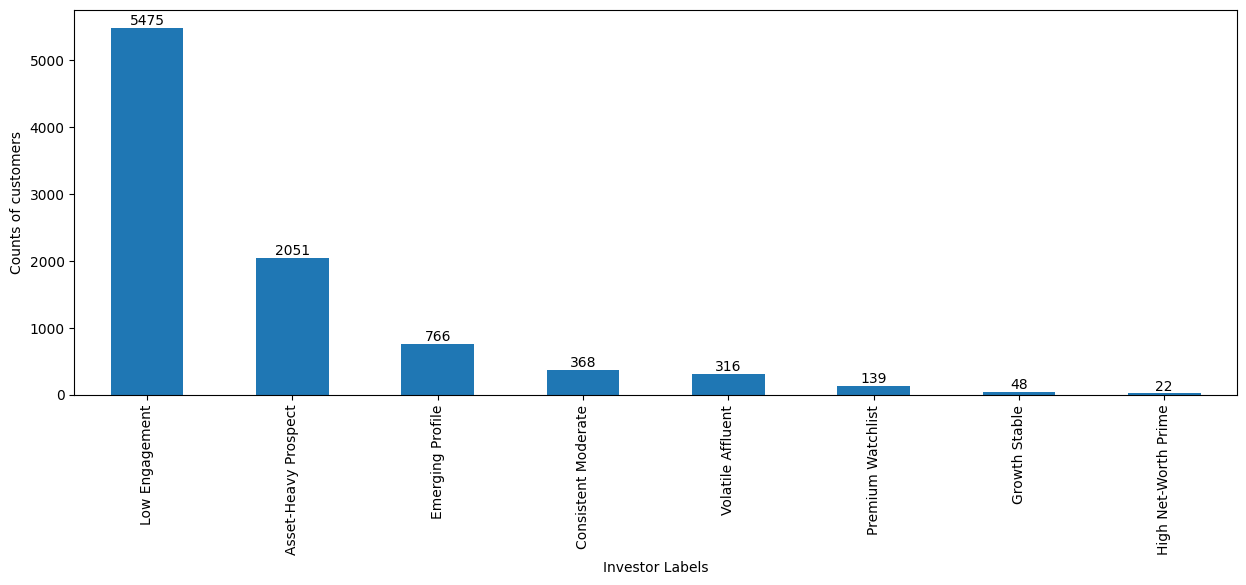

In [393]:
valCounts = df_analysis['Label'].value_counts()
valCounts

plt.figure(figsize=(15,5))

ax = valCounts.plot(kind='bar')
plt.xlabel('Investor Labels')
plt.ylabel('Counts of customers')
for cols in ax.containers:
    ax.bar_label(cols)
plt.show()

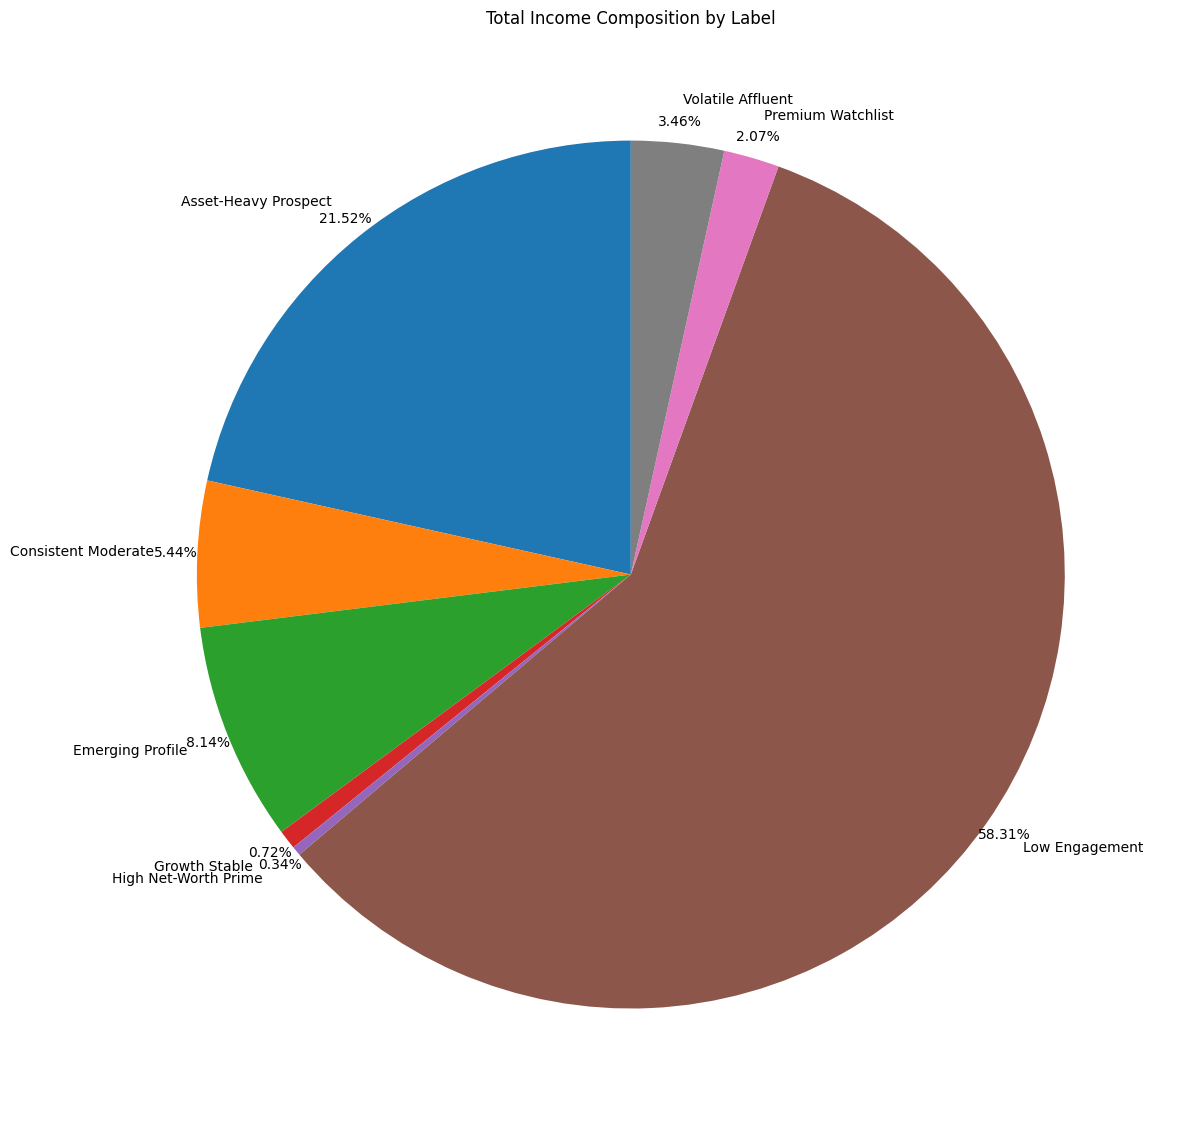

In [394]:
income_by_labels = df_analysis.groupby('Label')['Income'].sum()
income_by_labels

plt.figure(figsize=(12,12))

plt.pie(x=income_by_labels
        , labels=income_by_labels.index
        , startangle=90
        , autopct='%0.2f%%'
        , pctdistance=1.05
)
plt.title('Total Income Composition by Label')
plt.tight_layout()
plt.show()

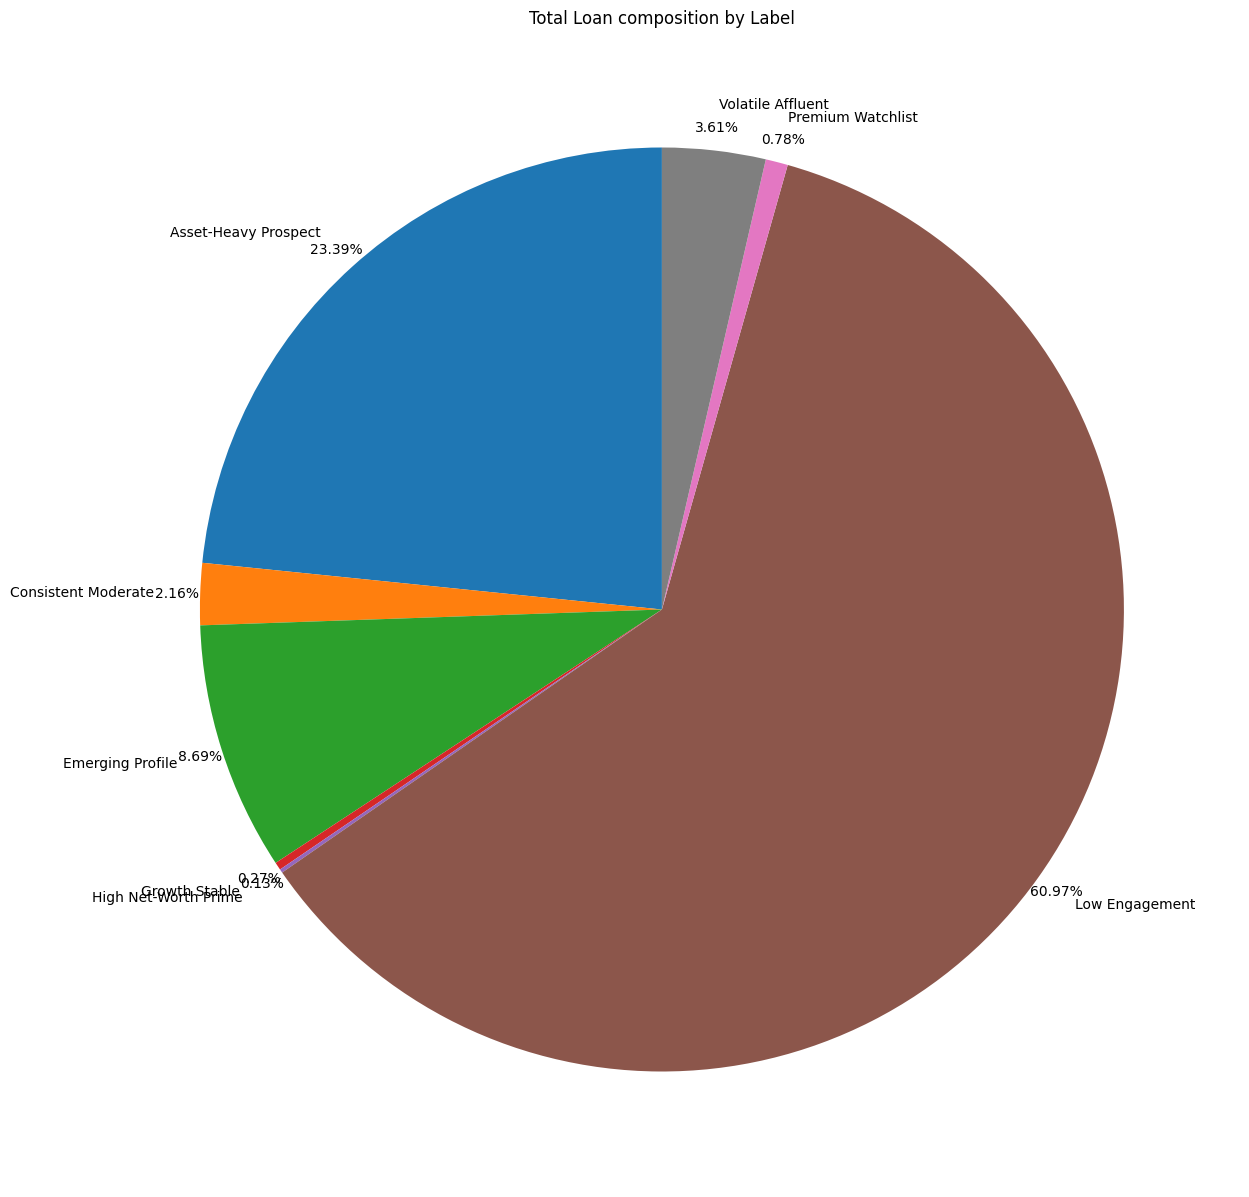

In [395]:
loan_df = df_analysis.groupby('Label')['Loan Amount'].sum()
loan_df
plt.figure(figsize=(15,15))
plt.pie(
    x = loan_df
    , labels=loan_df.index
    , autopct='%0.2f%%'
    , pctdistance=1.05
    , startangle= 90
)
plt.title('Total Loan composition by Label')
plt.show()

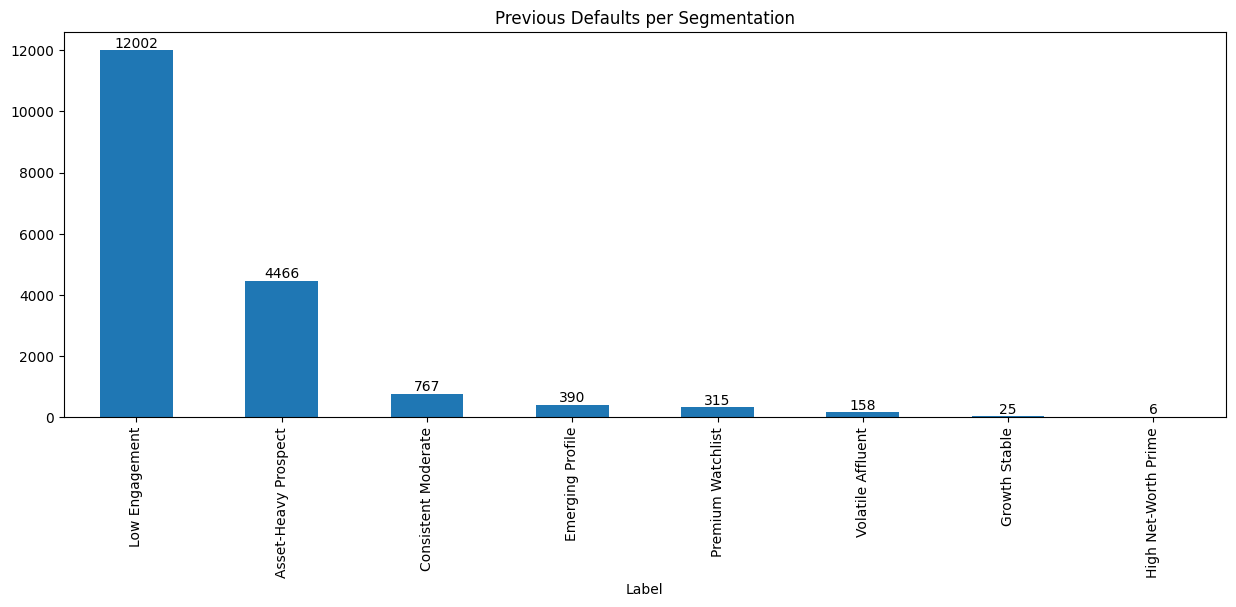

In [396]:
plt.figure(figsize=(15,5))

def_counts = round(df_analysis.groupby('Label')['Previous Defaults'].sum(), 0).sort_values(ascending = False)
ax = def_counts.plot(kind='bar')
for cols in ax.containers:
    ax.bar_label(cols)
plt.title('Previous Defaults per Segmentation')
plt.show()

<ul>
<li>The data strongly suggests that clients classified under the Low Engagement segment     exhibit the highest rates of previous defaults and lack strong financial stability or creditworthiness.
</ul>

<ul>
<li>Despite representing a significant portion of the loan portfolio, extending large loan amounts to this group increases the overall credit risk.
</ul>

<ul>
<li><b>Lenders should be cautious in offering substantial loans to low engagement segments and prioritize targeted engagement or basic financial education to reduce default risks.</b>
</ul>

<b>Asset-Heavy Prospects:</b>

<ul>
<li>Although their default rates are lower than low engagement clients, monitor recent stability fluctuations. Tailored monitoring protocols could be implemented for these individuals.
</ul>

<b>Volatile Affluent:</b>

<ul>
<li>While high in net worth, this group’s financial instability or sudden credit changes demand adaptive, flexible loan products and heightened monitoring to manage risk.
</ul>

<b>High Net-Worth Prime and Growth Stable:</b>

<ul>
<li>These segments have the highest income, credit scores, and asset values with consistently low default rates. They are ideal candidates for premium products and larger, long-term loans.
</ul>

<b>Cluster-Based Actions:</b>

<ul>
<li>Recommend periodic reviews for segments like the Premium Watchlist, and encourage asset-building or loyalty schemes for Consistent Moderate and Emerging Profile segments.
</ul>

## `K-Means Clustering`

In [397]:
cols_to_be_scale = df_analysis.select_dtypes(exclude=['str']).columns.tolist()

In [398]:
df_analysis_scaled = df_analysis.copy()

In [399]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [400]:
for col in cols_to_be_scale:
    df_analysis_scaled[col] = scaler.fit_transform(df_analysis_scaled[[col]])

In [401]:
df_analysis_scaled.drop(columns=['City', 'State', 'Country'], inplace=True)

In [402]:
df_analysis_scaled = pd.concat([df_analysis_scaled, pd.get_dummies(df_analysis_scaled['Gender']).astype('int64').drop(columns=['Non-binary'])], axis=1).drop(['Gender'], axis=1)
df_analysis_scaled

,Age,Education Level,Marital Status,Income,Credit Score,Loan Amount,Loan Purpose,Employment Status,Years at Current Job,Payment History,Debt-to-Income Ratio,Assets Value,Number of Dependents,Previous Defaults,Marital Status Change,Risk Rating,Label,Female,Male
0,0.380694,PhD,Divorced,0.098436,-0.192641,1.440992,Business,Unemployed,1.645230,Poor,-1.360896,-0.168708,-1.148013,0.018548,1.235951,Low,Low Engagement,0,1
2,-1.506594,Master's,Single,-0.485773,-1.733204,0.851105,Home,Employed,-0.252542,Fair,0.087387,0.478327,0.862889,0.725449,1.235951,Medium,Low Engagement,0,0
3,1.054725,Bachelor's,Single,-1.481955,-1.348063,0.196843,Personal,Unemployed,-1.287690,Excellent,0.731655,0.228157,0.862889,1.432351,1.235951,Medium,Low Engagement,0,1
4,-1.236981,Bachelor's,Widowed,-0.699492,1.172858,0.844940,Personal,Unemployed,0.092508,Fair,-1.437950,1.617209,-1.148013,0.725449,0.008021,Low,Low Engagement,0,0
6,-0.832563,Master's,Widowed,-0.841072,-0.472743,-1.100260,Personal,Self-employed,-1.460215,Good,0.202172,-1.455117,-1.148013,-1.395255,0.008021,Low,Low Engagement,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,-0.225934,High School,Married,-0.896550,-1.488114,0.717553,Home,Unemployed,0.265033,Poor,0.348407,-1.110810,1.533190,-0.688353,0.008021,Low,Low Engagement,0,1
14995,-1.371788,Bachelor's,Widowed,-0.745206,-1.575646,0.173870,Home,Self-employed,-1.287690,Fair,-0.224177,-1.455117,1.533190,0.018548,-1.219909,Low,Low Engagement,0,0
14996,0.852516,PhD,Single,1.272660,0.017436,0.752985,Auto,Self-employed,0.092508,Fair,-1.355242,-0.608745,-1.148013,-1.395255,-1.219909,Medium,Low Engagement,0,1
14997,-0.967369,PhD,Married,-0.807956,-0.997935,1.353774,Home,Unemployed,1.645230,Excellent,1.699345,0.651984,1.533190,0.018548,0.008021,High,Asset-Heavy Prospect,0,0


In [403]:
str_cols = df_analysis_scaled.select_dtypes(include=['str']).columns.tolist()

In [404]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [405]:
for col in str_cols:
    df_analysis_scaled[f'{col}_encoded'] = le.fit_transform(df_analysis_scaled[col])

In [406]:
df_analysis_scaled.drop(columns=str_cols, inplace=True)
df_analysis_scaled

,Age,Income,Credit Score,Loan Amount,Years at Current Job,Debt-to-Income Ratio,Assets Value,Number of Dependents,Previous Defaults,Marital Status Change,Female,Male,Education Level_encoded,Marital Status_encoded,Loan Purpose_encoded,Employment Status_encoded,Payment History_encoded,Risk Rating_encoded,Label_encoded
0,0.380694,0.098436,-0.192641,1.440992,1.645230,-1.360896,-0.168708,-1.148013,0.018548,1.235951,0,1,3,0,1,2,3,1,5
2,-1.506594,-0.485773,-1.733204,0.851105,-0.252542,0.087387,0.478327,0.862889,0.725449,1.235951,0,0,2,2,2,0,1,2,5
3,1.054725,-1.481955,-1.348063,0.196843,-1.287690,0.731655,0.228157,0.862889,1.432351,1.235951,0,1,0,2,3,2,0,2,5
4,-1.236981,-0.699492,1.172858,0.844940,0.092508,-1.437950,1.617209,-1.148013,0.725449,0.008021,0,0,0,3,3,2,1,1,5
6,-0.832563,-0.841072,-0.472743,-1.100260,-1.460215,0.202172,-1.455117,-1.148013,-1.395255,0.008021,0,0,2,3,3,1,2,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,-0.225934,-0.896550,-1.488114,0.717553,0.265033,0.348407,-1.110810,1.533190,-0.688353,0.008021,0,1,1,1,2,2,3,1,5
14995,-1.371788,-0.745206,-1.575646,0.173870,-1.287690,-0.224177,-1.455117,1.533190,0.018548,-1.219909,0,0,0,3,2,1,1,1,5
14996,0.852516,1.272660,0.017436,0.752985,0.092508,-1.355242,-0.608745,-1.148013,-1.395255,-1.219909,0,1,3,2,0,1,1,2,5
14997,-0.967369,-0.807956,-0.997935,1.353774,1.645230,1.699345,0.651984,1.533190,0.018548,0.008021,0,0,3,1,2,2,0,0,0


In [407]:
df_analysis.reset_index(inplace=True)

### `K-Means Clustering`

In [408]:
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

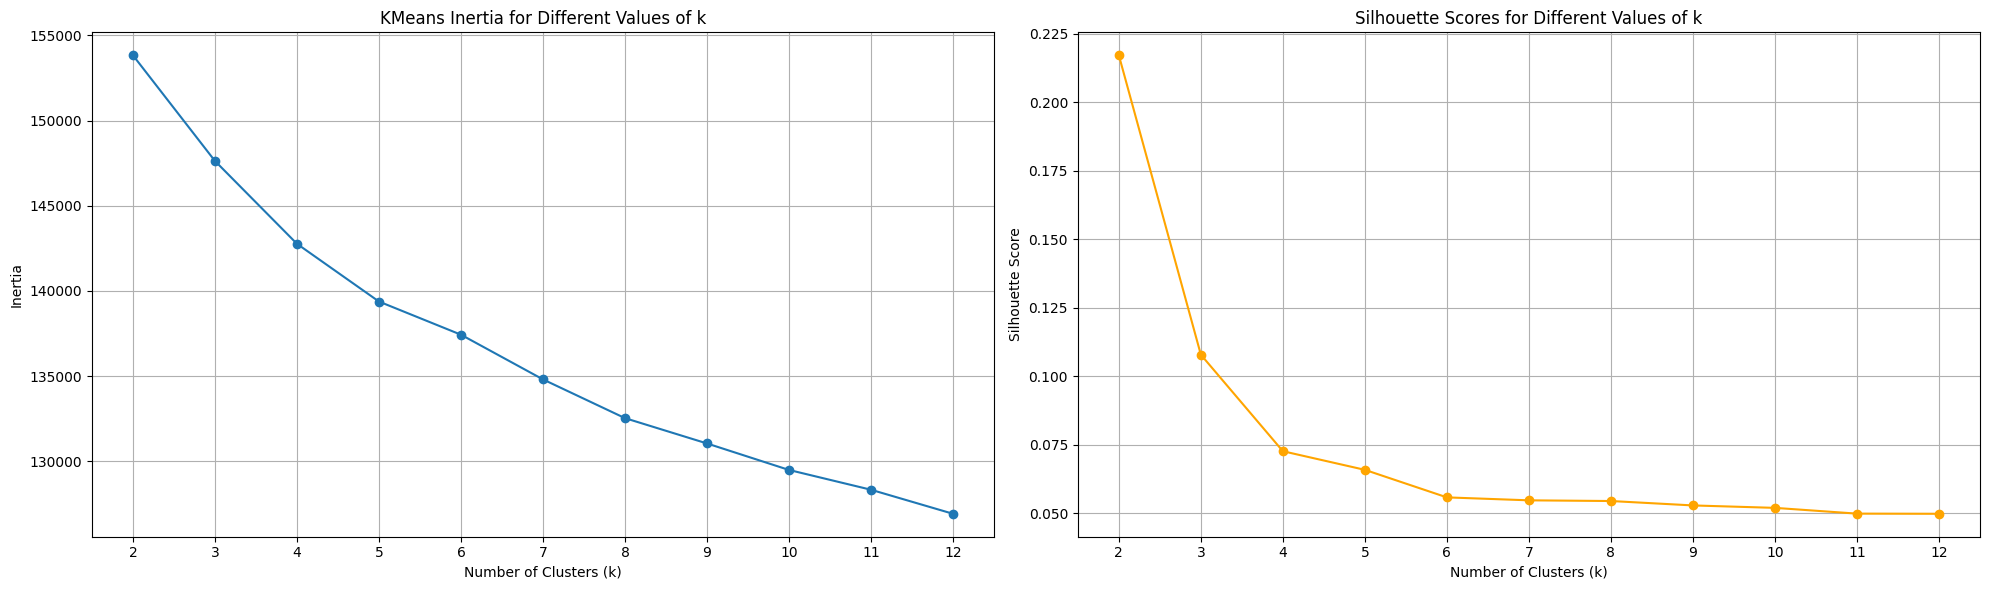

In [409]:
max_k = 12

inertia = []
silhoutte_scores = []
k_values = range(2, max_k + 1)

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000)

    cluster_labels = kmeans.fit_predict(df_analysis_scaled[
                                                            [
                                                            'Age',
                                                            'Income',
                                                            'Credit Score',
                                                            'Loan Amount',
                                                            'Years at Current Job',
                                                            'Debt-to-Income Ratio',
                                                            'Assets Value',
                                                            'Number of Dependents',
                                                            'Previous Defaults',
                                                            'Marital Status Change',
                                                            'Female',
                                                            'Male',
                                                            'Education Level_encoded',
                                                            'Marital Status_encoded',
                                                            'Loan Purpose_encoded',
                                                            'Employment Status_encoded',
                                                            'Payment History_encoded',
                                                            'Risk Rating_encoded',
                                                            'Label_encoded'
                                                            ]
                                                        ])

    sil_score = silhouette_score(df_analysis_scaled[
                                                    [
                                                            'Age',
                                                            'Income',
                                                            'Credit Score',
                                                            'Loan Amount',
                                                            'Years at Current Job',
                                                            'Debt-to-Income Ratio',
                                                            'Assets Value',
                                                            'Number of Dependents',
                                                            'Previous Defaults',
                                                            'Marital Status Change',
                                                            'Female',
                                                            'Male',
                                                            'Education Level_encoded',
                                                            'Marital Status_encoded',
                                                            'Loan Purpose_encoded',
                                                            'Employment Status_encoded',
                                                            'Payment History_encoded',
                                                            'Risk Rating_encoded',
                                                            'Label_encoded'
                                                            ]
                                                   ], cluster_labels)

    silhoutte_scores.append(sil_score)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 6))

plt.subplot(1, 2, 1)
plt.plot(k_values, inertia, marker='o')
plt.title('KMeans Inertia for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, silhoutte_scores, marker='o', color='orange')
plt.title('Silhouette Scores for Different Values of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

In [411]:
kmeans = KMeans(n_clusters=5, random_state=42, max_iter=1000)

cluster_labels = kmeans.fit_predict(df_analysis_scaled[[
                                                            'Age',
                                                            'Income',
                                                            'Credit Score',
                                                            'Loan Amount',
                                                            'Years at Current Job',
                                                            'Debt-to-Income Ratio',
                                                            'Assets Value',
                                                            'Number of Dependents',
                                                            'Previous Defaults',
                                                            'Marital Status Change',
                                                            'Female',
                                                            'Male',
                                                            'Education Level_encoded',
                                                            'Marital Status_encoded',
                                                            'Loan Purpose_encoded',
                                                            'Employment Status_encoded',
                                                            'Payment History_encoded',
                                                            'Risk Rating_encoded',
                                                            'Label_encoded'
                                                            ]
                                                            ])

cluster_labels

array([1, 2, 2, ..., 2, 0, 0], shape=(9185,), dtype=int32)

In [412]:
df_analysis_scaled['Cluster'] = cluster_labels
df_analysis_scaled.head()

,Age,Income,Credit Score,Loan Amount,Years at Current Job,Debt-to-Income Ratio,Assets Value,Number of Dependents,Previous Defaults,Marital Status Change,Female,Male,Education Level_encoded,Marital Status_encoded,Loan Purpose_encoded,Employment Status_encoded,Payment History_encoded,Risk Rating_encoded,Label_encoded,Cluster
0,0.380694,0.098436,-0.192641,1.440992,1.645230,-1.360896,-0.168708,-1.148013,0.018548,1.235951,0,1,3,0,1,2,3,1,5,1
2,-1.506594,-0.485773,-1.733204,0.851105,-0.252542,0.087387,0.478327,0.862889,0.725449,1.235951,0,0,2,2,2,0,1,2,5,2
3,1.054725,-1.481955,-1.348063,0.196843,-1.287690,0.731655,0.228157,0.862889,1.432351,1.235951,0,1,0,2,3,2,0,2,5,2
4,-1.236981,-0.699492,1.172858,0.844940,0.092508,-1.437950,1.617209,-1.148013,0.725449,0.008021,0,0,0,3,3,2,1,1,5,2
6,-0.832563,-0.841072,-0.472743,-1.100260,-1.460215,0.202172,-1.455117,-1.148013,-1.395255,0.008021,0,0,2,3,3,1,2,1,5,2


<b>1. Cluster 0: "Prime"</b><br>
Rationale: Top-tier, high net-worth clients with strong financial position, stable income, and very low risk. These are the most financially sound and consistent group, often with long-standing records of reliability.<br>
Action: Provide premium financial products, personalized wealth management, and proactive engagement. Offer exclusive investment opportunities and specialized portfolio reviews.<br>

<b>2. Cluster 1: "Watchlist"</b><br>
Rationale: Affluent clients who are generally stable but have recent credit/risk alerts or anomalies in history. They may require monitoring and occasional intervention to prevent risk escalation or financial deterioration.<br>
Action: Periodically review their credit behavior, offer targeted credit improvement products, and ensure timely communication around risk events or changes.<br>

<b>3. Cluster 2: "Asset Builder"</b><br>
Rationale: Reliable or emerging clients with good financial behavior and potential for strong asset growth, though not yet at prime status. They are on a good growth trajectory but need continued support.<br>
Action: Offer asset accumulation products (e.g. investment plans, savings schemes), educational resources for financial growth, and incentives for loyalty and stable engagement.<br>

<b>4. Cluster 3: "Volatile Affluent"</b><br>
Rationale: High net worth/capital, but with recent instability in income, employment, or credit. These clients can be high contributors but pose risk if instability persists.<br>
Action: Provide financial planning support and monitoring for sudden income or credit changes. Design flexible products and hedging solutions to buffer against volatility.<br>

<b>5. Cluster 4: "Low Engagement"</b><br>
Rationale: Clients lacking strong financial, stability, or credit markers. Generally lower contributors and may represent marginal segments.<br>
Action: Use onboarding, education, and basic engagement programs to nurture financial habits and encourage incremental portfolio growth.<br>

# <b>`Machine Learning`

## <b>`Preprocessing`

In [413]:
df_model.reset_index(inplace=True)

### `Feature Enginneering`

In [414]:
df_model['Gender'].unique().tolist()

['Male', 'Non-binary', 'Female']

In [415]:
pd.get_dummies(df_model['Gender']).astype('int64').drop(columns=['Non-binary']).head()

,Female,Male
0,0,1
1,0,0
2,0,1
3,0,0
4,0,0


In [416]:
df_model = pd.concat([df_model, pd.get_dummies(df_model['Gender']).astype('int64').drop(columns=['Non-binary'])], axis=1).drop(['Gender'], axis=1)

In [417]:
df_model.drop(['City', 'State', 'Country'], axis=1, inplace=True)

In [418]:
str_cols = df_model.select_dtypes(include=['str']).columns.tolist()

In [419]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [420]:
df_dummy = pd.DataFrame()

In [421]:
for col in str_cols:
    df_dummy[f'{col}_encoded'] = le.fit_transform(df_model[col])

In [422]:
df_model = pd.concat([df_model, df_dummy], axis=1)

In [423]:
df_model.drop(columns=str_cols, inplace=True)

## <b>`Model Training`

In [424]:
df_model.drop(columns=['index'], inplace=True)

In [425]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Risk Rating_encoded'], axis="columns")
y = df_model['Risk Rating_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [426]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [427]:
model_params = {
    'random_forest': {
        'model': RandomForestClassifier(),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2'],
            'bootstrap': [True, False]
        }
    },
    'logistic_regression': {
        'model': LogisticRegression(),
        'params': {
            'C': [0.01, 0.1, 1, 5, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga']
        }
    }
}

In [428]:
from sklearn.model_selection import GridSearchCV

In [429]:
scores = []

for model_name, mp in model_params.items():
    clf = GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False, n_jobs=-1)
    clf.fit(X_train, y_train)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_})
    
scores_df = pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
scores_df.sort_values(by='best_score', ascending=False, inplace=True)

scores_df

/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See http

,model,best_score,best_params
0,random_forest,0.606004,"{'bootstrap': True, 'max_depth': None, 'max_fe..."
1,logistic_regression,0.605693,"{'C': 0.01, 'penalty': 'l1', 'solver': 'saga'}"


In [430]:
model_rf = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42, bootstrap=True, max_features='sqrt', min_samples_leaf=1, min_samples_split=2)
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [431]:
y_pred_rf = model_rf.predict(X_test)

In [432]:
model_rf.score(X_test, y_test)

0.5979680696661829